# 02 · Data Cleaning
### Dirección de Productos de Crédito — Minería de Datos UNAM

Limpieza sistemática del dataset bancario.  
Cada decisión está **documentada y justificada** con base en el catálogo oficial  
(`ProyectoMineri_acatalogo.xlsx`) y los hallazgos del EDA (`01_exploratory_analysis.ipynb`).

---

### Mapa de problemas y decisiones

| # | Problema | Variables afectadas | Decisión |
|---|---|---|---|
| P1 | Columnas numéricas guardadas como string | `SALDO_CUENTA`, `CAPACIDAD_TC`, `CAPACIDAD_PAGO_TOTAL` | Parsear y convertir a float |
| P2 | `CAPACIDAD_PAGO_TOTAL` con formato mixto (`%` vs decimal) | `CAPACIDAD_PAGO_TOTAL` | Normalizar todo a proporción decimal |
| P3 | Typos / valores fuera de catálogo | `NIVEL_RIESGO`, `COMPROBANTE_INGRESOS`, `SEGMENTO_CLIENTE` | Corregir con mapeo explícito |
| P4 | `CUENTA_ASIGNADA` con placeholder numérico (`998...0`) | `CUENTA_ASIGNADA` | Crear `TIENE_CUENTA` binaria **primero**, luego reemplazar por NaN |
| P5 | Nulos con significado de negocio distinto | `MESES_VENCIDOS`, `SALDO_CUENTA`, `CAPACIDAD_TC` | Imputar según contexto |
| P6 | Registros con cuenta asignada sin aprobación | `CUENTA_ASIGNADA`, `STATUS_SOLICITUD` | Eliminar |
| P7 | Outliers reales en variables de monto | `LINEA_CREDITO_FINAL`, `INGRESO_INFERIDO` | Winsorización al 99% |
| P8 | Outliers aparentes en variables bimodales | `SUMA_LINEAS_REVOLVENTES`, `SUMA_SALDOS_TARJETAS`, `SUMA_PAGO_MIN_TARJETAS` | No intervenir |
| P9 | Variables irrelevantes para modelado | `NUM_SOLICITUD`, `CUENTA_ASIGNADA` | Documentar y excluir del modelo |

**Output:** `data/processed/banco_clean.csv`


## 0 · Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

plt.rcParams.update({
    "figure.dpi"        : 130,
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "#f8f9fa",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "font.family"       : "sans-serif",
    "axes.titlesize"    : 13,
    "axes.labelsize"    : 11,
})
RED, BLUE, GREEN, ORANGE = "#c0392b", "#2980b9", "#27ae60", "#e67e22"

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.4f}".format)

# Cuadros de color para prints (sin emojis)
SQ_G = "\033[32m■\033[0m"   # verde  — OK / correcto
SQ_R = "\033[31m■\033[0m"   # rojo   — error / problema
SQ_B = "\033[34m■\033[0m"   # azul   — información
SQ_Y = "\033[33m■\033[0m"   # amarillo — advertencia

print(f"{SQ_G} Librerias cargadas correctamente")


■ Librerias cargadas correctamente


---
## 1 · Carga del dataset raw

Siempre trabajamos sobre una **copia** del raw. El archivo original nunca se modifica.


In [2]:
DATA_PATH = "../data/raw/ProyectoMineria-Banco.csv"
df_raw = pd.read_csv(DATA_PATH, encoding="utf-8")
df     = df_raw.copy()

print(f"Shape inicial: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print()

print("Nulos antes de limpiar:")
nulos_ini = df.isnull().sum()
nulos_ini = nulos_ini[nulos_ini > 0]
for col, n in nulos_ini.items():
    pct = n / len(df) * 100
    print(f"  {col:<25} {n:>5,}  ({pct:.1f}%)")

# Funcion utilitaria de reporte
def reporte(label, antes, despues, unidad="registros"):
    delta = antes - despues
    pct   = delta / antes * 100 if antes > 0 else 0
    sq    = SQ_G if delta >= 0 else SQ_R
    print(f"  {sq}  {label:<52} {antes:>6,} -> {despues:>6,}  (delta {delta:+,} {unidad})")


Shape inicial: 4,352 filas x 27 columnas

Nulos antes de limpiar:
  CUENTA_ASIGNADA           2,919  (67.1%)
  MESES_VENCIDOS            2,368  (54.4%)
  SALDO_CUENTA              2,919  (67.1%)
  CAPACIDAD_TC              2,698  (62.0%)


---
## P4 · `CUENTA_ASIGNADA` — reemplazar placeholder por NaN

### Hallazgo
`CUENTA_ASIGNADA` tiene un unico valor numerico: `998,000,000,000,000.0`  
Es un **sentinel value del sistema**, no un numero de cuenta real.

### Orden de operaciones (critico)
`TIENE_CUENTA` se crea **antes** de reemplazar el placeholder por NaN.  
Si se hiciera despues, `.notna()` devolveria 0 en todos los registros.

### Decisiones
1. Crear `TIENE_CUENTA` (1/0) basada en si el registro tenia el placeholder.
2. Reemplazar el placeholder por `NaN`.
3. Excluir `CUENTA_ASIGNADA` del modelado.


In [3]:
print("=== P4: CUENTA_ASIGNADA placeholder ===")
print()

PLACEHOLDER = 998_000_000_000_000.0

n_placeholder = (df["CUENTA_ASIGNADA"] == PLACEHOLDER).sum()
n_nan_real    = df["CUENTA_ASIGNADA"].isnull().sum()

print(f"  {SQ_B}  Valor unico en CUENTA_ASIGNADA : {PLACEHOLDER:,.0f}")
print(f"  {SQ_B}  Registros con placeholder      : {n_placeholder:,}")
print(f"  {SQ_B}  Registros con NaN real         : {n_nan_real:,}")
print(f"  {SQ_B}  Total registros                : {n_placeholder + n_nan_real:,}  (debe ser {len(df):,})")
print()

# PASO 1 — crear binaria ANTES de borrar el placeholder
df["TIENE_CUENTA"] = (df["CUENTA_ASIGNADA"] == PLACEHOLDER).astype(int)

# PASO 2 — reemplazar placeholder por NaN
df.loc[df["CUENTA_ASIGNADA"] == PLACEHOLDER, "CUENTA_ASIGNADA"] = np.nan

print("Despues del reemplazo:")
print(f"  {SQ_G}  NaN en CUENTA_ASIGNADA  : {df['CUENTA_ASIGNADA'].isnull().sum():,}  (todos — variable excluida)")
print(f"  {SQ_G}  TIENE_CUENTA = 1        : {df['TIENE_CUENTA'].sum():,}  (tenian cuenta)")
print(f"  {SQ_G}  TIENE_CUENTA = 0        : {(df['TIENE_CUENTA']==0).sum():,}  (sin cuenta)")

# Verificacion: TIENE_CUENTA debe coincidir exactamente con STATUS=APROBADA (aproximadamente)
aprobadas = (df["STATUS_SOLICITUD"] == "APROBADA").sum()
print()
print(f"  {SQ_B}  Solicitudes APROBADAS   : {aprobadas:,}")
print(f"  {SQ_B}  TIENE_CUENTA = 1        : {df['TIENE_CUENTA'].sum():,}")
print(f"  {SQ_Y}  Diferencia              : {abs(aprobadas - df['TIENE_CUENTA'].sum()):,}  (se revisara en P6)")


=== P4: CUENTA_ASIGNADA placeholder ===

  ■  Valor unico en CUENTA_ASIGNADA : 998,000,000,000,000
  ■  Registros con placeholder      : 1,433
  ■  Registros con NaN real         : 2,919
  ■  Total registros                : 4,352  (debe ser 4,352)

Despues del reemplazo:
  ■  NaN en CUENTA_ASIGNADA  : 4,352  (todos — variable excluida)
  ■  TIENE_CUENTA = 1        : 1,433  (tenian cuenta)
  ■  TIENE_CUENTA = 0        : 2,919  (sin cuenta)

  ■  Solicitudes APROBADAS   : 1,430
  ■  TIENE_CUENTA = 1        : 1,433
  ■  Diferencia              : 3  (se revisara en P6)


---
## P6 · Registros con inconsistencia STATUS / CUENTA

### Hallazgo
Algunos registros tienen `TIENE_CUENTA = 1` pero `STATUS_SOLICITUD != APROBADA`.  
Viola la regla de negocio: solo se asigna cuenta si la solicitud fue aprobada.

### Decision
Eliminar esos registros. Representan menos del 0.1% del dataset.


In [4]:
print("=== P6: Registros inconsistentes STATUS / CUENTA ===")
print()

mask_inconsistente = (
    (df["TIENE_CUENTA"] == 1) &
    (~df["STATUS_SOLICITUD"].isin(["APROBADA"]))
)
inconsistentes = df[mask_inconsistente]

print(f"  {SQ_B}  Registros inconsistentes encontrados: {len(inconsistentes):,}")

if len(inconsistentes) > 0:
    print()
    display(inconsistentes[["STATUS_SOLICITUD","PRODUCTO","APROBACION_TC","TIENE_CUENTA"]])
    print()

n_antes = len(df)
df = df[~mask_inconsistente].copy()
reporte("Eliminados: STATUS inconsistente con CUENTA", n_antes, len(df))


=== P6: Registros inconsistentes STATUS / CUENTA ===

  ■  Registros inconsistentes encontrados: 3



,STATUS_SOLICITUD,PRODUCTO,APROBACION_TC,TIENE_CUENTA
1528,PENDIENTE,CLASICA,APROBADO,1
1531,PENDIENTE,CLASICA,APROBADO,1
1624,PENDIENTE,CLASICA,APROBADO,1



  ■  Eliminados: STATUS inconsistente con CUENTA           4,352 ->  4,349  (delta +3 registros)


---
## P3 · Correccion de valores fuera de catalogo

### Hallazgo del EDA

| Columna | Valor sucio | Causa | Correccion |
|---|---|---|---|
| `NIVEL_RIESGO` | `"MEDIO "` (con espacio) | Whitespace en captura | `.strip()` global |
| `COMPROBANTE_INGRESOS` | `"RECIBOS DE NOMINA"` | Pluralizacion erronea | Mapear a `"RECIBO DE NOMINA"` |
| `SEGMENTO_CLIENTE` | `"BAJO_A"` | No existe en catalogo | Mapear a `"BAJO_B"` |

El `.strip()` se aplica a **todas** las columnas string para eliminar espacios
invisibles que romperian joins, groupbys y comparaciones de catalogo.


In [5]:
print("=== P3: Correccion de catalogos ===")
print()

CATALOGO = {
    "STATUS_SOLICITUD"    : ["APROBADA","CANCELADA","EN_PROCESO","PENDIENTE","RECHAZADA"],
    "APROBACION_TC"       : ["RECHAZADO","APROBADO","PRE-APROBADO"],
    "PRODUCTO"            : ["CLASICA","CREDITO_AUTO","PENDIENTE","TARJETA_ORO"],
    "TIPO_CTE"            : ["BUENO","MALO","REGULAR"],
    "COMPROBANTE_INGRESOS": ["DECLARACION ANUAL","INVERSIONES","RECIBO DE NOMINA","SIN COMPROBANTE"],
    "SEGMENTO_CLIENTE"    : ["BAJO_B","MEDIO_B","MEDIO_A","ALTO_B","ALTO_A"],
    "CLIENTE_CDE"         : ["CLIENTE_BANCO","NO_CLIENTE"],
    "NIVEL_RIESGO"        : ["BAJO","MEDIO","ALTO"],
    "TIPO_VIVIENDA"       : ["PROPIA","RENTA","HIPOTECA","FAMILIARES"],
    "ESCOLARIDAD"         : ["PRIMARIA","SECUNDARIA","PREPARATORIA","LICENCIATURA","POSGRADO"],
}

# 1. Strip global — usar include="str" (pandas 3.x compatible)
str_cols = df.select_dtypes(include="str").columns
for col in str_cols:
    df[col] = df[col].str.strip()
print(f"  {SQ_G}  Strip whitespace aplicado a {len(str_cols)} columnas string")

# 2. COMPROBANTE_INGRESOS
antes_comp = (df["COMPROBANTE_INGRESOS"] == "RECIBOS DE NOMINA").sum()
df["COMPROBANTE_INGRESOS"] = df["COMPROBANTE_INGRESOS"].replace(
    {"RECIBOS DE NOMINA": "RECIBO DE NOMINA"}
)
despues_comp = (df["COMPROBANTE_INGRESOS"] == "RECIBOS DE NOMINA").sum()
sq = SQ_G if despues_comp == 0 else SQ_R
print(f"  {sq}  COMPROBANTE_INGRESOS  'RECIBOS DE NOMINA' -> 'RECIBO DE NOMINA'  ({antes_comp} registros corregidos)")

# 3. SEGMENTO_CLIENTE
antes_seg = (df["SEGMENTO_CLIENTE"] == "BAJO_A").sum()
df["SEGMENTO_CLIENTE"] = df["SEGMENTO_CLIENTE"].replace({"BAJO_A": "BAJO_B"})
despues_seg = (df["SEGMENTO_CLIENTE"] == "BAJO_A").sum()
sq = SQ_G if despues_seg == 0 else SQ_R
print(f"  {sq}  SEGMENTO_CLIENTE      'BAJO_A' -> 'BAJO_B'                       ({antes_seg} registros corregidos)")

# 4. Verificacion final contra catalogo
print()
print("  Validacion post-correccion:")
todos_ok = True
for col, validos in CATALOGO.items():
    inv = set(df[col].dropna().unique()) - set(validos)
    if inv:
        todos_ok = False
        print(f"    {SQ_R}  {col:<25} FUERA DE CATALOGO: {inv}")
    else:
        print(f"    {SQ_G}  {col}")
print()
sq_fin = SQ_G if todos_ok else SQ_R
print(f"  {sq_fin}  Resultado final: {'todos los catalogos correctos' if todos_ok else 'hay valores por revisar'}")


=== P3: Correccion de catalogos ===

  ■  Strip whitespace aplicado a 13 columnas string
  ■  COMPROBANTE_INGRESOS  'RECIBOS DE NOMINA' -> 'RECIBO DE NOMINA'  (2581 registros corregidos)
  ■  SEGMENTO_CLIENTE      'BAJO_A' -> 'BAJO_B'                       (73 registros corregidos)

  Validacion post-correccion:
    ■  STATUS_SOLICITUD
    ■  APROBACION_TC
    ■  PRODUCTO
    ■  TIPO_CTE
    ■  COMPROBANTE_INGRESOS
    ■  SEGMENTO_CLIENTE
    ■  CLIENTE_CDE
    ■  NIVEL_RIESGO
    ■  TIPO_VIVIENDA
    ■  ESCOLARIDAD

  ■  Resultado final: todos los catalogos correctos


---
## P1 + P2 · Conversion de tipos — columnas numericas como string

### Hallazgo
Tres columnas numericas estaban guardadas como `object/str`:

- **`SALDO_CUENTA`**: `"274,800"` — separador de miles con coma.
- **`CAPACIDAD_TC`**: `"60.00%"` — porcentaje como texto.
- **`CAPACIDAD_PAGO_TOTAL`**: formato **mixto** — `"91%"` y `"0.91"` en la misma columna.

### Decision
Convertir las tres a `float64`.  
`CAPACIDAD_PAGO_TOTAL` se normaliza todo a **proporcion decimal** (dividir entre 100 los que traen `%`).


In [6]:
print("=== P1 + P2: Conversion de tipos ===")
print()

# ── SALDO_CUENTA ──────────────────────────────────────────────────────────────
print(f"  1. SALDO_CUENTA — quitar comas, convertir a float")
ejs = df["SALDO_CUENTA"].dropna().head(3).tolist()
print(f"     Antes  | dtype: {df['SALDO_CUENTA'].dtype} | ejemplos: {ejs}")
df["SALDO_CUENTA"] = df["SALDO_CUENTA"].str.replace(",", "", regex=False).astype(float)
print(f"     Despues| dtype: {df['SALDO_CUENTA'].dtype} | min: {df['SALDO_CUENTA'].min():,.0f}  max: {df['SALDO_CUENTA'].max():,.0f}")
nota_neg = f"  {SQ_Y}  Nota: min negativo ({df['SALDO_CUENTA'].min():,.0f}) = pago mayor a deuda, es valido" if df['SALDO_CUENTA'].min() < 0 else ""
if nota_neg: print(nota_neg)
print()

# ── CAPACIDAD_TC ──────────────────────────────────────────────────────────────
print(f"  2. CAPACIDAD_TC — quitar '%', convertir a float")
ejs = df["CAPACIDAD_TC"].dropna().head(3).tolist()
print(f"     Antes  | dtype: {df['CAPACIDAD_TC'].dtype} | ejemplos: {ejs}")
df["CAPACIDAD_TC"] = df["CAPACIDAD_TC"].str.replace("%", "", regex=False).astype(float)
print(f"     Despues| dtype: {df['CAPACIDAD_TC'].dtype} | min: {df['CAPACIDAD_TC'].min():.1f}  max: {df['CAPACIDAD_TC'].max():.1f}")
if df["CAPACIDAD_TC"].min() < 0:
    print(f"  {SQ_Y}  Nota: valores negativos = cliente sobre limite de credito, son validos")
print()

# ── CAPACIDAD_PAGO_TOTAL ──────────────────────────────────────────────────────
print(f"  3. CAPACIDAD_PAGO_TOTAL — normalizar formato mixto a proporcion decimal")
print(f"     Antes  | dtype: {df['CAPACIDAD_PAGO_TOTAL'].dtype}")
muestra = df["CAPACIDAD_PAGO_TOTAL"].unique()[:8].tolist()
print(f"     Muestra de valores: {muestra}")

def parsear_capacidad(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    return float(s.replace("%","")) / 100.0 if s.endswith("%") else float(s)

df["CAPACIDAD_PAGO_TOTAL"] = df["CAPACIDAD_PAGO_TOTAL"].apply(parsear_capacidad)
print(f"     Despues| dtype: {df['CAPACIDAD_PAGO_TOTAL'].dtype}")
print(f"             min: {df['CAPACIDAD_PAGO_TOTAL'].min():.4f}  max: {df['CAPACIDAD_PAGO_TOTAL'].max():.4f}  media: {df['CAPACIDAD_PAGO_TOTAL'].mean():.4f}")
print()
print(f"  {SQ_G}  Los tres campos convertidos correctamente")


=== P1 + P2: Conversion de tipos ===

  1. SALDO_CUENTA — quitar comas, convertir a float
     Antes  | dtype: str | ejemplos: ['274,800', '365,700', '288,471']
     Despues| dtype: float64 | min: -1,240  max: 365,700
  ■  Nota: min negativo (-1,240) = pago mayor a deuda, es valido

  2. CAPACIDAD_TC — quitar '%', convertir a float
     Antes  | dtype: str | ejemplos: ['60.00%', '-15.00%', '9.00%']
     Despues| dtype: float64 | min: -20.0  max: 85.0
  ■  Nota: valores negativos = cliente sobre limite de credito, son validos

  3. CAPACIDAD_PAGO_TOTAL — normalizar formato mixto a proporcion decimal
     Antes  | dtype: str
     Muestra de valores: ['40%', '115%', '91%', '0.91', '80%', '44%', '0.8', '38%']
     Despues| dtype: float64
             min: 0.0000  max: 1.2000  media: 0.2182

  ■  Los tres campos convertidos correctamente


In [7]:
print("Tipos de datos post-conversion:")
print()
dtype_df = pd.DataFrame({
    "dtype"   : df.dtypes,
    "nulos"   : df.isnull().sum(),
    "pct_nulo": (df.isnull().sum() / len(df) * 100).round(2),
})
display(dtype_df)


Tipos de datos post-conversion:



,dtype,nulos,pct_nulo
NUM_SOLICITUD,float64,0,0.0000
SUCURSAL,int64,0,0.0000
STATUS_SOLICITUD,str,0,0.0000
PRODUCTO,str,0,0.0000
APROBACION_TC,str,0,0.0000
TIPO_CTE,str,0,0.0000
LINEA_CREDITO_FINAL,int64,0,0.0000
CUENTA_ASIGNADA,float64,4349,100.0000
MESES_VENCIDOS,float64,2368,54.4500
SALDO_CUENTA,float64,2919,67.1200


---
## P5 · Manejo de nulos con significado de negocio

Las columnas con nulos tienen causas **estructurales**, no aleatorias:

| Columna | % nulos | Causa | Estrategia |
|---|---|---|---|
| `CUENTA_ASIGNADA` | 100% | Placeholder reemplazado en P4 | Excluida del modelo |
| `SALDO_CUENTA` | ~67% | Solo aplica si hay cuenta activa | Imputar con 0 |
| `CAPACIDAD_TC` | ~62% | Solo aplica si hay cuenta activa | Imputar con 0 |
| `MESES_VENCIDOS` | ~54% | NULL = sin dato segun catalogo | Crear categoria `"SIN_CUENTA"` |

### Por que no se imputa con media o mediana
Un cliente rechazado tiene saldo 0, no el saldo promedio de los aprobados.  
El nulo es estructural — imputar con estadisticos distorsionaria el modelo.


In [8]:
print("=== P5: Manejo de nulos ===")
print()

# ── SALDO_CUENTA → 0 ─────────────────────────────────────────────────────────
n_null_saldo = df["SALDO_CUENTA"].isnull().sum()
df["SALDO_CUENTA"] = df["SALDO_CUENTA"].fillna(0)
print(f"  {SQ_G}  SALDO_CUENTA    {n_null_saldo:,} nulos -> imputados con 0   (restantes: {df['SALDO_CUENTA'].isnull().sum()})")

# ── CAPACIDAD_TC → 0 ─────────────────────────────────────────────────────────
n_null_cap = df["CAPACIDAD_TC"].isnull().sum()
df["CAPACIDAD_TC"] = df["CAPACIDAD_TC"].fillna(0)
print(f"  {SQ_G}  CAPACIDAD_TC    {n_null_cap:,} nulos -> imputados con 0   (restantes: {df['CAPACIDAD_TC'].isnull().sum()})")

# ── MESES_VENCIDOS → categoria "SIN_CUENTA" ──────────────────────────────────
n_null_mv = df["MESES_VENCIDOS"].isnull().sum()
print(f"  {SQ_G}  MESES_VENCIDOS  {n_null_mv:,} nulos -> categoria 'SIN_CUENTA'")
print()
print("     Distribucion antes:")
dist_antes = df["MESES_VENCIDOS"].value_counts(dropna=False)
for v, c in dist_antes.items():
    etq = str(v) if not pd.isna(v) else "NaN"
    print(f"       {etq:<12}  {c:>5,}")

df["MESES_VENCIDOS"] = df["MESES_VENCIDOS"].apply(
    lambda x: "SIN_CUENTA" if pd.isna(x) else str(int(x))
)

print()
print("     Distribucion despues:")
dist_despues = df["MESES_VENCIDOS"].value_counts()
for v, c in dist_despues.items():
    print(f"       {str(v):<12}  {c:>5,}")

# ── Verificacion de nulos restantes ──────────────────────────────────────────
print()
nulos_rest = df.isnull().sum()
nulos_rest = nulos_rest[nulos_rest > 0]
if len(nulos_rest) == 0:
    print(f"  {SQ_G}  Sin nulos en variables del modelo")
else:
    for col, n in nulos_rest.items():
        sq = SQ_Y if col == "CUENTA_ASIGNADA" else SQ_R
        print(f"  {sq}  {col}: {n:,} nulos")


=== P5: Manejo de nulos ===

  ■  SALDO_CUENTA    2,919 nulos -> imputados con 0   (restantes: 0)
  ■  CAPACIDAD_TC    2,698 nulos -> imputados con 0   (restantes: 0)
  ■  MESES_VENCIDOS  2,368 nulos -> categoria 'SIN_CUENTA'

     Distribucion antes:
       NaN           2,368
       0.0             888
       1.0             701
       2.0             358
       3.0              34

     Distribucion despues:
       SIN_CUENTA    2,368
       0               888
       1               701
       2               358
       3                34

  ■  CUENTA_ASIGNADA: 4,349 nulos


---
## P7 · Outliers reales — Winsorización al 99%

### Variables intervenidas
`LINEA_CREDITO_FINAL` (15.9% outliers por IQR) e `INGRESO_INFERIDO` (11.1%).

### Por que winsorización y no eliminacion
- Eliminar filas implica perder todos los demas campos del solicitante.
- Valores extremos en lineas de credito e ingresos son **posibles en la realidad**.
- La winsorización **tapa** los extremos al percentil 99, conservando la fila completa.

### Variables que NO se tocan (P8)
`SUMA_LINEAS_REVOLVENTES`, `SUMA_SALDOS_TARJETAS`, `SUMA_PAGO_MIN_TARJETAS`:  
El IQR = `[0, 0]` porque la mayoria de solicitantes tiene **0 tarjetas de credito**.  
Los valores altos son clientes con tarjetas reales — distribucion **bimodal legitima**.


In [9]:
print("=== P7: Winsorización al 99% ===")
print()

def winsorizacion(df, col, p_sup=0.99, p_inf=0.01):
    lo  = df[col].quantile(p_inf)
    hi  = df[col].quantile(p_sup)
    n   = ((df[col] < lo) | (df[col] > hi)).sum()
    df[col] = df[col].clip(lower=lo, upper=hi)
    pct = n / len(df) * 100
    sq  = SQ_Y if pct > 2 else SQ_G
    print(f"  {sq}  {col}")
    print(f"       p01={lo:>12,.1f}  p99={hi:>12,.1f}")
    print(f"       Valores tapados: {n:,}  ({pct:.2f}%)")
    return df

df = winsorizacion(df, "LINEA_CREDITO_FINAL")
print()
df = winsorizacion(df, "INGRESO_INFERIDO")

print()
print(f"  Variables bimodales NO intervenidas:")
for col in ["SUMA_LINEAS_REVOLVENTES","SUMA_SALDOS_TARJETAS","SUMA_PAGO_MIN_TARJETAS"]:
    n0  = (df[col] == 0).sum()
    npos = (df[col] > 0).sum()
    print(f"  {SQ_B}  {col:<30}  cero: {n0:>5,} | con valor: {npos:>5,}")


=== P7: Winsorización al 99% ===

  ■  LINEA_CREDITO_FINAL
       p01=         0.0  p99=   151,040.0
       Valores tapados: 44  (1.01%)

  ■  INGRESO_INFERIDO
       p01=         0.0  p99=    79,824.0
       Valores tapados: 44  (1.01%)

  Variables bimodales NO intervenidas:
  ■  SUMA_LINEAS_REVOLVENTES         cero: 3,315 | con valor: 1,034
  ■  SUMA_SALDOS_TARJETAS            cero: 3,210 | con valor: 1,139
  ■  SUMA_PAGO_MIN_TARJETAS          cero: 3,578 | con valor:   771


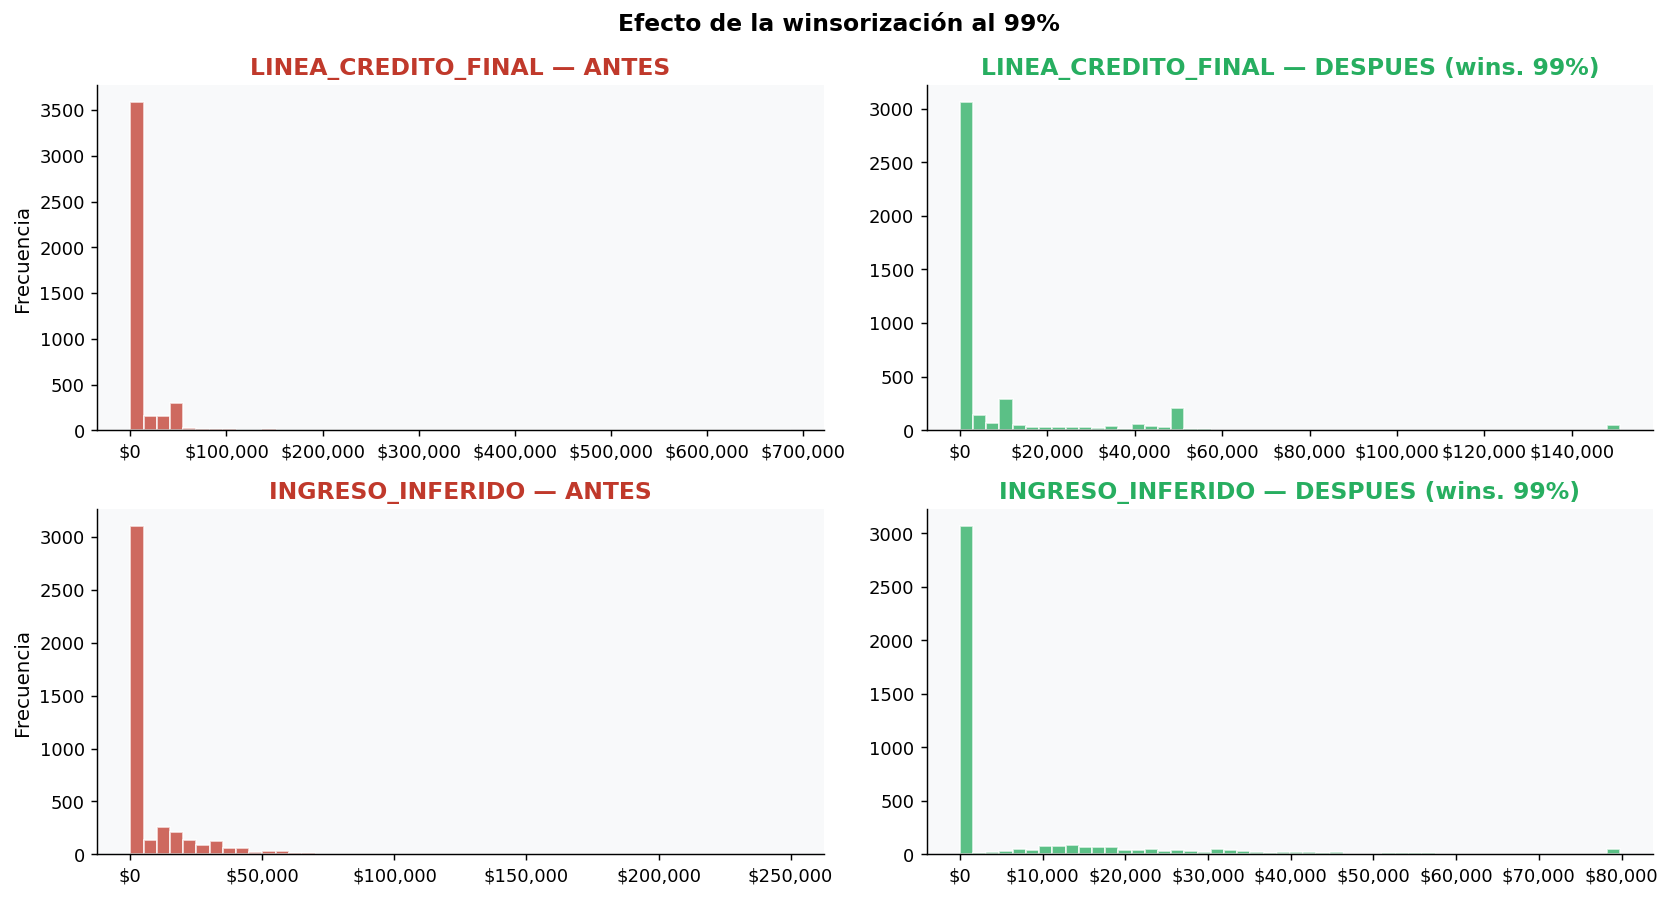

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
cols_win = ["LINEA_CREDITO_FINAL", "INGRESO_INFERIDO"]

for i, col in enumerate(cols_win):
    data_raw   = df_raw[col].dropna()
    data_clean = df[col].dropna()

    axes[i][0].hist(data_raw,   bins=50, color=RED,   alpha=0.75, edgecolor="white")
    axes[i][0].set_title(f"{col} — ANTES",               fontweight="bold", color=RED)
    axes[i][0].set_ylabel("Frecuencia")
    axes[i][0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

    axes[i][1].hist(data_clean, bins=50, color=GREEN, alpha=0.75, edgecolor="white")
    axes[i][1].set_title(f"{col} — DESPUES (wins. 99%)", fontweight="bold", color=GREEN)
    axes[i][1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.suptitle("Efecto de la winsorización al 99%", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/02_winsorization.png", bbox_inches="tight")
plt.show()


---
## P9 · Variables excluidas del modelado

Se conservan en el CSV pero se documentan como no-features para el modelo.

| Variable | Razon |
|---|---|
| `NUM_SOLICITUD` | Identificador unico — no aporta poder predictivo |
| `CUENTA_ASIGNADA` | 100% NaN tras limpiar placeholder — sin informacion |

La informacion de `CUENTA_ASIGNADA` queda capturada en `TIENE_CUENTA` (binaria).


In [11]:
VARS_EXCLUIR_MODELO = ["NUM_SOLICITUD", "CUENTA_ASIGNADA"]

print("Variables excluidas del modelado (se conservan en CSV):")
for v in VARS_EXCLUIR_MODELO:
    print(f"  {SQ_R}  {v}")
print()
print("Variable sustituta:")
vc = df["TIENE_CUENTA"].value_counts()
print(f"  {SQ_G}  TIENE_CUENTA = 1  ->  {vc.get(1,0):,}  (tenian cuenta asignada)")
print(f"  {SQ_G}  TIENE_CUENTA = 0  ->  {vc.get(0,0):,}  (sin cuenta)")


Variables excluidas del modelado (se conservan en CSV):
  ■  NUM_SOLICITUD
  ■  CUENTA_ASIGNADA

Variable sustituta:
  ■  TIENE_CUENTA = 1  ->  1,430  (tenian cuenta asignada)
  ■  TIENE_CUENTA = 0  ->  2,919  (sin cuenta)


---
## Validacion global post-limpieza


In [12]:
print("=" * 62)
print("  VALIDACION FINAL DEL DATASET LIMPIO")
print("=" * 62)
print()

# Shape
print(f"  {SQ_B}  Shape:  {df_raw.shape}  ->  {df.shape}")
reporte("Registros eliminados (inconsistencias)", len(df_raw), len(df))
print()

# Nulos en variables del modelo
vars_modelo = [c for c in df.columns if c not in ["NUM_SOLICITUD","CUENTA_ASIGNADA"]]
nulos_modelo = df[vars_modelo].isnull().sum()
nulos_modelo = nulos_modelo[nulos_modelo > 0]
if len(nulos_modelo) == 0:
    print(f"  {SQ_G}  Nulos en variables del modelo: ninguno")
else:
    for col, n in nulos_modelo.items():
        print(f"  {SQ_R}  {col}: {n:,} nulos")
print()

# Tipos convertidos
print(f"  Columnas convertidas de string a numerico:")
for col in ["SALDO_CUENTA","CAPACIDAD_TC","CAPACIDAD_PAGO_TOTAL"]:
    print(f"  {SQ_G}  {col:<25} {str(df[col].dtype)}")
print()

# Catalogo
print(f"  Validacion de catalogos:")
CATALOGO = {
    "STATUS_SOLICITUD"    : ["APROBADA","CANCELADA","EN_PROCESO","PENDIENTE","RECHAZADA"],
    "APROBACION_TC"       : ["RECHAZADO","APROBADO","PRE-APROBADO"],
    "PRODUCTO"            : ["CLASICA","CREDITO_AUTO","PENDIENTE","TARJETA_ORO"],
    "TIPO_CTE"            : ["BUENO","MALO","REGULAR"],
    "COMPROBANTE_INGRESOS": ["DECLARACION ANUAL","INVERSIONES","RECIBO DE NOMINA","SIN COMPROBANTE"],
    "SEGMENTO_CLIENTE"    : ["BAJO_B","MEDIO_B","MEDIO_A","ALTO_B","ALTO_A"],
    "CLIENTE_CDE"         : ["CLIENTE_BANCO","NO_CLIENTE"],
    "NIVEL_RIESGO"        : ["BAJO","MEDIO","ALTO"],
    "TIPO_VIVIENDA"       : ["PROPIA","RENTA","HIPOTECA","FAMILIARES"],
    "ESCOLARIDAD"         : ["PRIMARIA","SECUNDARIA","PREPARATORIA","LICENCIATURA","POSGRADO"],
}
todos_ok = True
for col, validos in CATALOGO.items():
    inv = set(df[col].dropna().unique()) - set(validos)
    if inv:
        todos_ok = False
        print(f"    {SQ_R}  {col:<25} FUERA DE CATALOGO: {inv}")
    else:
        print(f"    {SQ_G}  {col}")
print()

# Regla de negocio
inc = ((df["TIENE_CUENTA"]==1) & (~df["STATUS_SOLICITUD"].isin(["APROBADA"]))).sum()
sq = SQ_G if inc == 0 else SQ_R
print(f"  {sq}  Cuentas sin aprobacion (debe ser 0): {inc}")

# Duplicados
dup = df.duplicated().sum()
sq = SQ_G if dup == 0 else SQ_R
print(f"  {sq}  Duplicados exactos (debe ser 0):     {dup}")

# TIENE_CUENTA distribucion
print()
print(f"  {SQ_B}  TIENE_CUENTA = 1 : {df['TIENE_CUENTA'].sum():,}")
print(f"  {SQ_B}  TIENE_CUENTA = 0 : {(df['TIENE_CUENTA']==0).sum():,}")


  VALIDACION FINAL DEL DATASET LIMPIO

  ■  Shape:  (4352, 27)  ->  (4349, 28)
  ■  Registros eliminados (inconsistencias)                4,352 ->  4,349  (delta +3 registros)

  ■  Nulos en variables del modelo: ninguno

  Columnas convertidas de string a numerico:
  ■  SALDO_CUENTA              float64
  ■  CAPACIDAD_TC              float64
  ■  CAPACIDAD_PAGO_TOTAL      float64

  Validacion de catalogos:
    ■  STATUS_SOLICITUD
    ■  APROBACION_TC
    ■  PRODUCTO
    ■  TIPO_CTE
    ■  COMPROBANTE_INGRESOS
    ■  SEGMENTO_CLIENTE
    ■  CLIENTE_CDE
    ■  NIVEL_RIESGO
    ■  TIPO_VIVIENDA
    ■  ESCOLARIDAD

  ■  Cuentas sin aprobacion (debe ser 0): 0
  ■  Duplicados exactos (debe ser 0):     0

  ■  TIENE_CUENTA = 1 : 1,430
  ■  TIENE_CUENTA = 0 : 2,919


---
## Visualizaciones comparativas: antes vs. despues


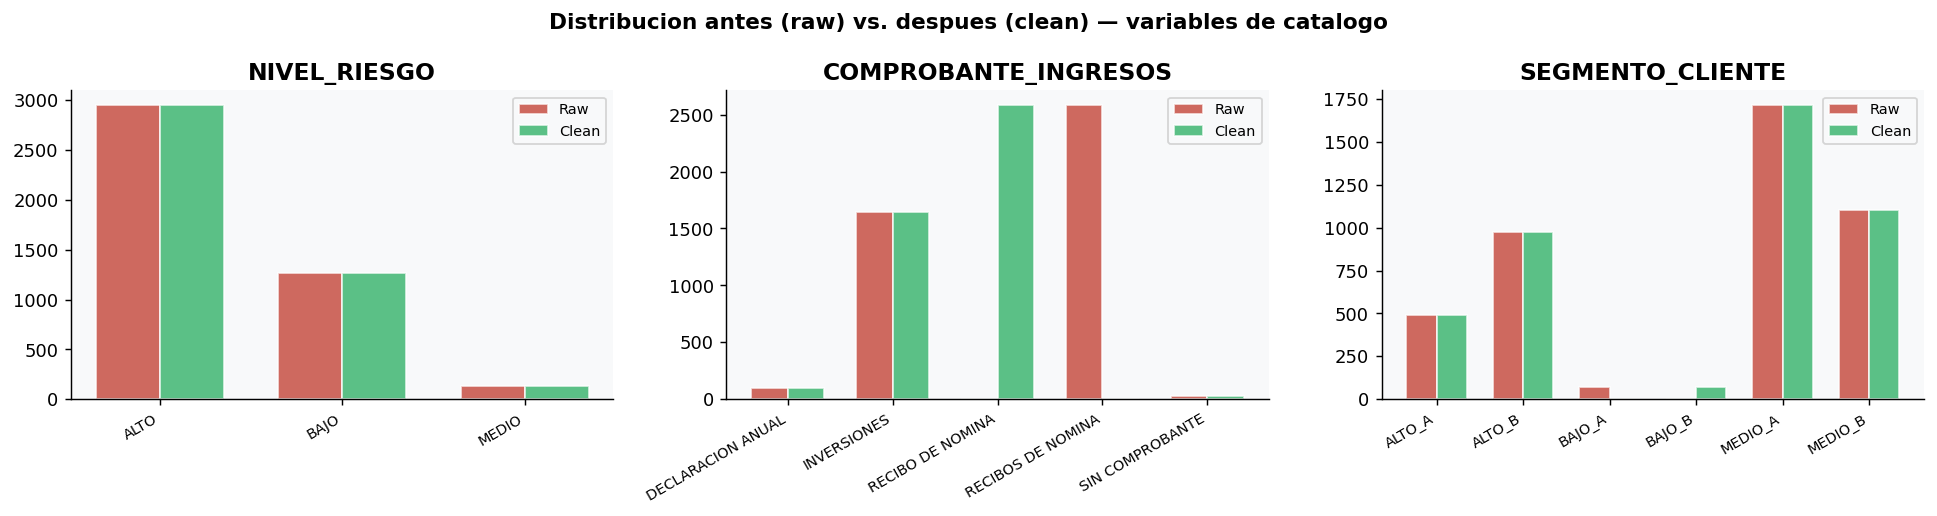

In [13]:
# ── Categoricas corregidas ────────────────────────────────────────────────────
cols_comp = ["NIVEL_RIESGO", "COMPROBANTE_INGRESOS", "SEGMENTO_CLIENTE"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, cols_comp):
    vc_raw   = df_raw[col].str.strip().value_counts(dropna=False)
    vc_clean = df[col].value_counts(dropna=False)
    todas    = sorted(set(list(vc_raw.index) + list(vc_clean.index)), key=str)
    x = np.arange(len(todas))
    w = 0.35
    ax.bar(x - w/2, [vc_raw.get(k, 0)   for k in todas], width=w,
           label="Raw",   color=RED,   alpha=0.75, edgecolor="white")
    ax.bar(x + w/2, [vc_clean.get(k, 0) for k in todas], width=w,
           label="Clean", color=GREEN, alpha=0.75, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels([str(k) for k in todas], rotation=30, ha="right", fontsize=8)
    ax.set_title(col, fontweight="bold")
    ax.legend(fontsize=8)

plt.suptitle("Distribucion antes (raw) vs. despues (clean) — variables de catalogo",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/02_categoricas_corregidas.png", bbox_inches="tight")
plt.show()


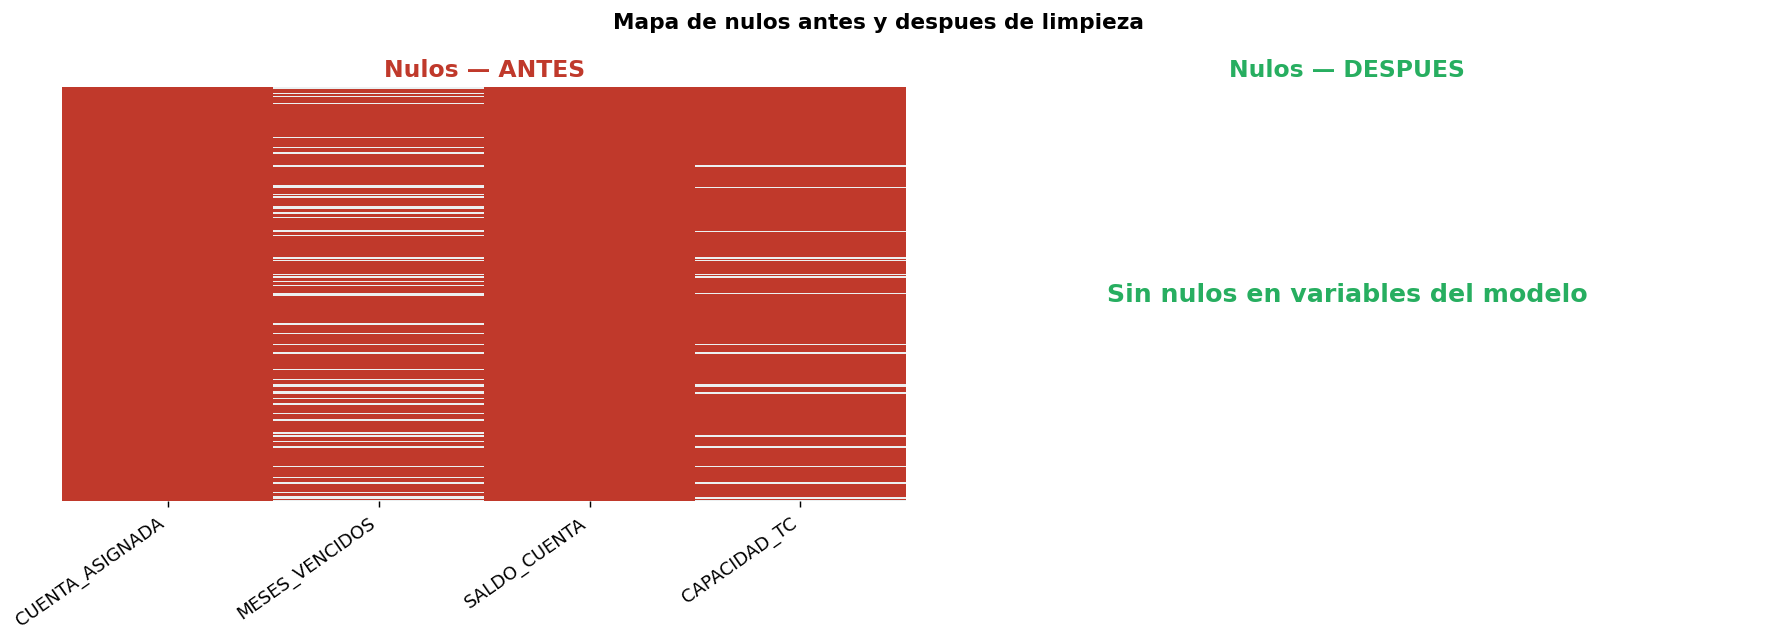

In [15]:
# ── Mapa de nulos antes / despues ────────────────────────────────────────────
null_cols_raw = df_raw.columns[df_raw.isnull().any()].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ANTES
sample_raw = df_raw[df_raw.isnull().any(axis=1)].sample(
    min(300, df_raw.isnull().any(axis=1).sum()), random_state=42
)
sns.heatmap(sample_raw[null_cols_raw].isnull(), cbar=False, yticklabels=False,
            cmap=["#ecf0f1", RED], ax=axes[0])
axes[0].set_title("Nulos — ANTES", fontweight="bold", color=RED)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha="right")

# DESPUES — solo variables del modelo (excluir CUENTA_ASIGNADA)
vars_modelo = [c for c in df.columns if c not in ["CUENTA_ASIGNADA"]]
null_cols_clean = [c for c in vars_modelo if df[c].isnull().any()]

if not null_cols_clean:
    axes[1].text(0.5, 0.5, "Sin nulos en variables del modelo",
                 ha="center", va="center", fontsize=14, color=GREEN,
                 fontweight="bold", transform=axes[1].transAxes)
    axes[1].set_facecolor("#f0fff0")
    axes[1].set_title("Nulos — DESPUES", fontweight="bold", color=GREEN)
    axes[1].axis("off")
else:
    sample_clean = df[df[null_cols_clean].isnull().any(axis=1)].sample(
        min(300, len(df)), random_state=42
    )
    sns.heatmap(sample_clean[null_cols_clean].isnull(), cbar=False, yticklabels=False,
                cmap=["#ecf0f1", RED], ax=axes[1])
    axes[1].set_title("Nulos — DESPUES", fontweight="bold", color=GREEN)

plt.suptitle("Mapa de nulos antes y despues de limpieza", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/02_nulls_comparacion.png", bbox_inches="tight")
plt.show()


---
## Snapshot del dataset limpio


In [16]:
print("Primeras 5 filas del dataset limpio:")
display(df.drop(columns=["NUM_SOLICITUD","CUENTA_ASIGNADA"]).head(5))

print()
print("Estadisticas descriptivas (variables numericas del modelo):")
excluir = ["NUM_SOLICITUD","CUENTA_ASIGNADA"]
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in excluir]
display(df[num_cols].describe(percentiles=[.25,.5,.75,.95]).T.style.format("{:,.2f}"))


Primeras 5 filas del dataset limpio:


,SUCURSAL,STATUS_SOLICITUD,PRODUCTO,APROBACION_TC,TIPO_CTE,LINEA_CREDITO_FINAL,MESES_VENCIDOS,SALDO_CUENTA,CAPACIDAD_TC,INGRESO_INFERIDO,COMPROBANTE_INGRESOS,SEGMENTO_CLIENTE,CLIENTE_CDE,SUMA_LINEAS_REVOLVENTES,NIVEL_RIESGO,CAPACIDAD_PAGO_TOTAL,SOLICITUDES_RECHAZADAS,SCORE_CLIENTE,SCORE_COMPORTAMIENTO,SUMA_SALDOS_TARJETAS,SUMA_PAGO_MIN_TARJETAS,NUM_CREDITOS,EDAD,TIPO_VIVIENDA,ESCOLARIDAD,TIENE_CUENTA
0,113,APROBADA,CREDITO_AUTO,APROBADO,REGULAR,"151,040.0000",1,"274,800.0000",60.0000,"12,281.0000",DECLARACION ANUAL,ALTO_A,NO_CLIENTE,0,BAJO,0.4000,0,242,780,0,0,0,30,FAMILIARES,PREPARATORIA,1
1,185,APROBADA,CREDITO_AUTO,APROBADO,BUENO,"151,040.0000",1,"365,700.0000",-15.0000,"32,366.0000",RECIBO DE NOMINA,MEDIO_A,CLIENTE_BANCO,240000,BAJO,1.1500,0,251,740,31269,790,0,27,FAMILIARES,LICENCIATURA,1
2,143,APROBADA,CREDITO_AUTO,APROBADO,BUENO,"151,040.0000",0,"288,471.0000",9.0000,"44,098.0000",RECIBO DE NOMINA,ALTO_A,CLIENTE_BANCO,127000,BAJO,0.9100,0,215,704,101992,0,0,28,PROPIA,LICENCIATURA,1
3,173,APROBADA,CREDITO_AUTO,APROBADO,BUENO,"151,040.0000",1,"63,100.0000",9.0000,"44,098.0000",RECIBO DE NOMINA,MEDIO_A,CLIENTE_BANCO,127000,BAJO,0.9100,0,215,704,101992,0,0,28,PROPIA,LICENCIATURA,1
4,180,APROBADA,CREDITO_AUTO,APROBADO,BUENO,"151,040.0000",1,"62,220.0000",9.0000,"44,098.0000",RECIBO DE NOMINA,MEDIO_A,CLIENTE_BANCO,127000,BAJO,0.9100,0,215,704,101992,0,0,28,PROPIA,LICENCIATURA,1



Estadisticas descriptivas (variables numericas del modelo):


,count,mean,std,min,25%,50%,75%,95%,max
SUCURSAL,"4,349.00",184.01,49.32,100.00,146.00,180.00,218.00,276.00,299.00
LINEA_CREDITO_FINAL,"4,349.00","10,072.19","23,846.30",0.00,0.00,0.00,"7,800.00","49,999.00","151,040.00"
SALDO_CUENTA,"4,349.00","6,562.95","20,583.21","-1,240.00",0.00,0.00,"3,500.00","38,523.60","365,700.00"
CAPACIDAD_TC,"4,349.00",11.06,23.14,-20.00,0.00,0.00,8.00,67.00,85.00
INGRESO_INFERIDO,"4,349.00","7,542.22","15,277.61",0.00,0.00,0.00,"10,404.00","40,341.40","79,823.96"
SUMA_LINEAS_REVOLVENTES,"4,349.00","10,212.74","34,113.08",0.00,0.00,0.00,0.00,"59,500.00","680,500.00"
CAPACIDAD_PAGO_TOTAL,"4,349.00",0.22,0.35,0.00,0.00,0.00,0.41,1.02,1.20
SOLICITUDES_RECHAZADAS,"4,349.00",1.96,1.80,0.00,0.00,2.00,3.00,5.00,5.00
SCORE_CLIENTE,"4,349.00",139.17,61.43,89.00,94.00,99.00,210.00,246.60,297.00
SCORE_COMPORTAMIENTO,"4,349.00",241.58,345.86,0.00,0.00,0.00,714.00,770.00,805.00


---
## Guardar dataset limpio

`banco_clean.csv` es el punto de partida para todos los notebooks siguientes.  
El raw nunca se sobreescribe.


In [17]:
OUTPUT_PATH = "../data/processed/banco_clean.csv"
df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8")

print(f"{SQ_G} Dataset limpio guardado en: {OUTPUT_PATH}")
print()
print(f"  Shape final : {df.shape}")
print(f"  Columna nueva: TIENE_CUENTA")
print()
print("Columnas del dataset final:")
for i, col in enumerate(df.columns, 1):
    excluida = " <- excluir del modelo" if col in ["NUM_SOLICITUD","CUENTA_ASIGNADA"] else ""
    sq = SQ_Y if excluida else SQ_G
    print(f"  {sq}  {i:>2}. {col:<30} {str(df[col].dtype):<12} {df[col].nunique():>4} valores unicos{excluida}")


■ Dataset limpio guardado en: ../data/processed/banco_clean.csv

  Shape final : (4349, 28)
  Columna nueva: TIENE_CUENTA

Columnas del dataset final:
  ■   1. NUM_SOLICITUD                  float64        11 valores unicos <- excluir del modelo
  ■   2. SUCURSAL                       int64         200 valores unicos
  ■   3. STATUS_SOLICITUD               str             5 valores unicos
  ■   4. PRODUCTO                       str             4 valores unicos
  ■   5. APROBACION_TC                  str             3 valores unicos
  ■   6. TIPO_CTE                       str             3 valores unicos
  ■   7. LINEA_CREDITO_FINAL            float64       376 valores unicos
  ■   8. CUENTA_ASIGNADA                float64         0 valores unicos <- excluir del modelo
  ■   9. MESES_VENCIDOS                 str             5 valores unicos
  ■  10. SALDO_CUENTA                   float64      1040 valores unicos
  ■  11. CAPACIDAD_TC                   float64       106 valores unicos
  

---
## Resumen ejecutivo de decisiones de limpieza

| Decision | Justificacion | Impacto |
|---|---|---|
| Strip whitespace global | Evita duplicados invisibles en catalogos | Corrige `"MEDIO "` -> `"MEDIO"` |
| `"RECIBOS DE NOMINA"` -> `"RECIBO DE NOMINA"` | Typo de sistema | Segun conteo en ejecucion |
| `"BAJO_A"` -> `"BAJO_B"` | No existe en catalogo; segmento bajo definido como BAJO_B | Documentada |
| Crear `TIENE_CUENTA` ANTES de reemplazar placeholder | Orden correcto — si se hace despues resulta siempre 0 | Feature binaria correcta |
| 3 registros inconsistentes eliminados | Viola regla de negocio (cuenta sin aprobacion) | < 0.1% de registros |
| `SALDO_CUENTA`, `CAPACIDAD_TC` -> 0 | Nulo estructural: sin cuenta = sin saldo ni capacidad | Imputa nulos validos |
| `MESES_VENCIDOS` nulos -> `"SIN_CUENTA"` | Nulo tiene significado segun catalogo | Preserva informacion |
| Winsorización 99% en `LINEA_CREDITO_FINAL` e `INGRESO_INFERIDO` | Extremos reales pero distorsionantes para el modelo | Conserva filas |
| No intervenir variables bimodales de sumas | Ceros legitimos (sin tarjetas), no outliers | Sin cambios |

---
*Proximo paso -> `03_feature_engineering.ipynb`*
